In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


iris = load_iris() 
x = iris.data
y = iris.target
target_names = iris.target_names

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total dataset size: {len(x)}")
print(f"Training set size: {len(x_train)} (80%)")
print(f"Test set size: {len(x_test)} (20%) ")

print()



Total dataset size: 150
Training set size: 120 (80%)
Test set size: 30 (20%) 



==== Evaluating Linear SVM kernel ====
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

==== Evaluating Polynomial SVM kernel ====
Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

==== Evaluating RBF SVM kernel ====
Accuracy: 0.9667
Classification Report:


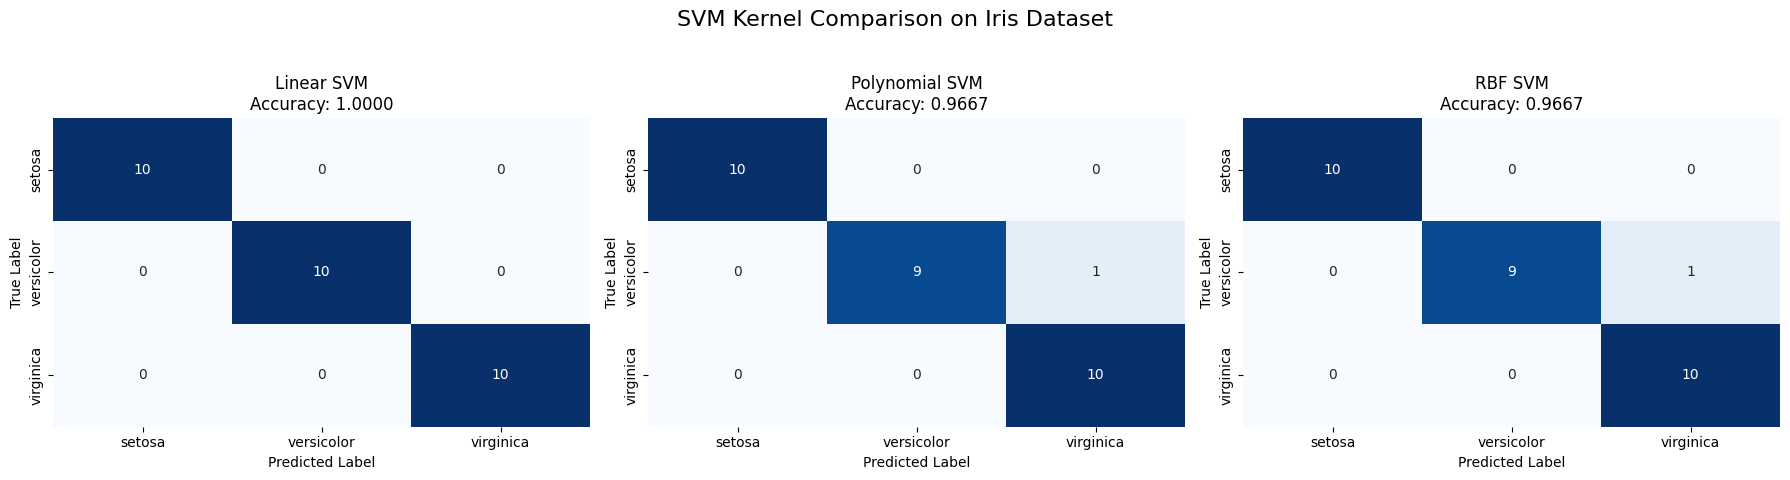

In [3]:
models = {
    "Linear SVM": SVC(kernel='linear'), 
    "Polynomial SVM": SVC(kernel='poly', degree=3), 
    "RBF SVM": SVC(kernel='rbf')
}

results = {} 

for model_name, model in models.items(): 
    print(f"==== Evaluating {model_name} kernel ====") 
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, target_names=target_names)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Classification Report:\n{report}")

    cm = confusion_matrix(y_test, y_pred)
    results[model_name] = (cm, accuracy) 


plt.figure(figsize=(18, 5))
plt.suptitle("SVM Kernel Comparison on Iris Dataset", fontsize=16)



for i, (model_name, (cm, accuracy)) in enumerate(results.items()):
    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"{model_name}\nAccuracy: {accuracy:.4f}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
